# Hebrew University MBA Corpus — EDA

**Goal:** Understand the corpus before any chunking or model decisions.  
**Scope:** Content, structure, language, and data-quality facts only.  
**Sources:** 30 URLs across 3 groups — `bschool` (6), `shnaton_roadmap` (7), `shnaton_specialization` (17).

**Run `eda.py` before opening this notebook.** It scrapes, extracts, and builds `data/corpus.parquet`.

> **Data correction history:** Two fixes were applied to the Shnaton scraper before this notebook was finalized. (1) Added the `/yearly-roadmaps/{id}/thresholds?year=YEAR` call to fetch course lists. (2) Discovered — by reading the Shnaton React app's JS bundle — that specializations require `/specializations/{user_code}/thresholds?activeYear=YEAR&thresholdYear=YEAR&include=courses` using the **user-facing code** (e.g. `3111`), not the internal db id (`45`). The db id resolved to a completely unrelated humanities yearly-roadmap entity. All cells below reflect the fully corrected corpus where all 17 specializations contain their complete MBA course catalogs (501–2,060 words each, 835 course entries total).

---

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────────
RAG_EDA_DIR = Path(".").resolve()
DATA_DIR = RAG_EDA_DIR / "data"
CLEAN_DIR = DATA_DIR / "clean"
FIGURES_DIR = RAG_EDA_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

CORPUS_PARQUET = DATA_DIR / "corpus.parquet"
BOILERPLATE_PARQUET = DATA_DIR / "boilerplate_ngrams.parquet"
JACCARD_NPY = DATA_DIR / "jaccard_matrix.npy"

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
sns.set_style("whitegrid")

GROUP_PALETTE = {
    "bschool": "#2c7bb6",
    "shnaton_roadmap": "#d7191c",
    "shnaton_specialization": "#1a9641",
}

print("Libraries loaded.")

Libraries loaded.


In [2]:
corpus_df = pd.read_parquet(CORPUS_PARQUET)
print(f"Corpus loaded: {len(corpus_df)} rows × {len(corpus_df.columns)} columns")
corpus_df.dtypes

Corpus loaded: 30 rows × 40 columns


url                             object
group                           object
title                           object
extension                       object
last_modified                   object
fetched_at                      object
raw_size_bytes                   int64
char_count                       int64
word_count                       int64
paragraph_count                  int64
avg_paragraph_length_words     float64
h1_count                         int64
h2_count                         int64
h3_count                         int64
list_item_count                  int64
table_row_count                  int64
digit_char_ratio               float64
numeric_line_ratio             float64
course_code_count                int64
credit_mention_count             int64
semester_mention_count           int64
gpa_mention_count                int64
year_mention_count               int64
hebrew_ratio                   float64
english_ratio                  float64
digit_ratio              

---
## Section 1 — Corpus Overview

High-level inventory: how many documents, from which source groups, when fetched, and how large on disk.

**Why it matters:** A clean manifest is the foundation of every downstream step — it tells us what we actually have.

In [3]:
# Source group breakdown
group_counts = corpus_df["group"].value_counts().rename_axis("group").reset_index(name="count")
print("Source group counts:")
print(group_counts.to_string(index=False))

print(f"\nTotal sources: {len(corpus_df)}")
print(f"Fetch errors (word_count == 0): {(corpus_df['word_count'] == 0).sum()}")

Source group counts:
                 group  count
shnaton_specialization     17
       shnaton_roadmap      7
               bschool      6

Total sources: 30
Fetch errors (word_count == 0): 0


In [4]:
# Manifest table: URL, group, title, size on disk, fetched_at
overview_cols = ["group", "url", "title", "extension", "raw_size_bytes", "last_modified", "fetched_at"]
available_cols = [c for c in overview_cols if c in corpus_df.columns]
manifest_display_df = corpus_df[available_cols].copy()
manifest_display_df["raw_size_kb"] = (manifest_display_df["raw_size_bytes"] / 1024).round(1)
manifest_display_df = manifest_display_df.drop(columns=["raw_size_bytes"])
manifest_display_df["url_short"] = manifest_display_df["url"].str.replace(r"https?://", "", regex=True).str[:60]

print(manifest_display_df[["group", "url_short", "extension", "raw_size_kb", "last_modified"]].to_string(index=False))

                 group                                                    url_short extension  raw_size_kb                 last_modified
               bschool                            bschool.huji.ac.il/mba/admittance     .html         97.5 Wed, 03 Jun 2026 18:01:03 GMT
               bschool                       bschool.huji.ac.il/mba/specializations     .html        118.6 Wed, 03 Jun 2026 18:15:37 GMT
               bschool                                    bschool.huji.ac.il/ptorim     .html        336.6 Wed, 03 Jun 2026 18:01:32 GMT
               bschool                   bschool.huji.ac.il/Accelerated-study-track     .html        121.5 Wed, 03 Jun 2026 18:32:34 GMT
               bschool               bschool.huji.ac.il/Accelerated-study-track-all     .html        108.4 Wed, 03 Jun 2026 18:32:36 GMT
               bschool bschool.huji.ac.il/sites/default/files/business/files/academ      .pdf       1825.8 Thu, 19 Mar 2026 09:07:03 GMT
       shnaton_roadmap                   

---
## Section 2 — Document Length Distribution

We measure **character count, word count, and paragraph count** per document.

**Why it matters:** If documents have very different lengths, a single fixed chunk size will work poorly — the PDF may be 100× longer than a specialization page. Knowing the spread drives the chunking budget decision.

In [5]:
# Descriptive stats by group
length_stats_by_group = (
    corpus_df
    .groupby("group")[["char_count", "word_count", "paragraph_count"]]
    .agg(["min", "median", "max"])
    .round(0)
)
print("Length statistics by source group:")
print(length_stats_by_group)

Length statistics by source group:
                       char_count                 word_count                 \
                              min  median     max        min  median    max   
group                                                                         
bschool                      2434  7974.0  120656        416  1302.0  20021   
shnaton_roadmap               333  3216.0   15166         68   658.0   3265   
shnaton_specialization       2352  5424.0    9783        501  1118.0   2060   

                       paragraph_count             
                                   min median max  
group                                              
bschool                             14   24.0  69  
shnaton_roadmap                      7   13.0  17  
shnaton_specialization              13   21.0  25  


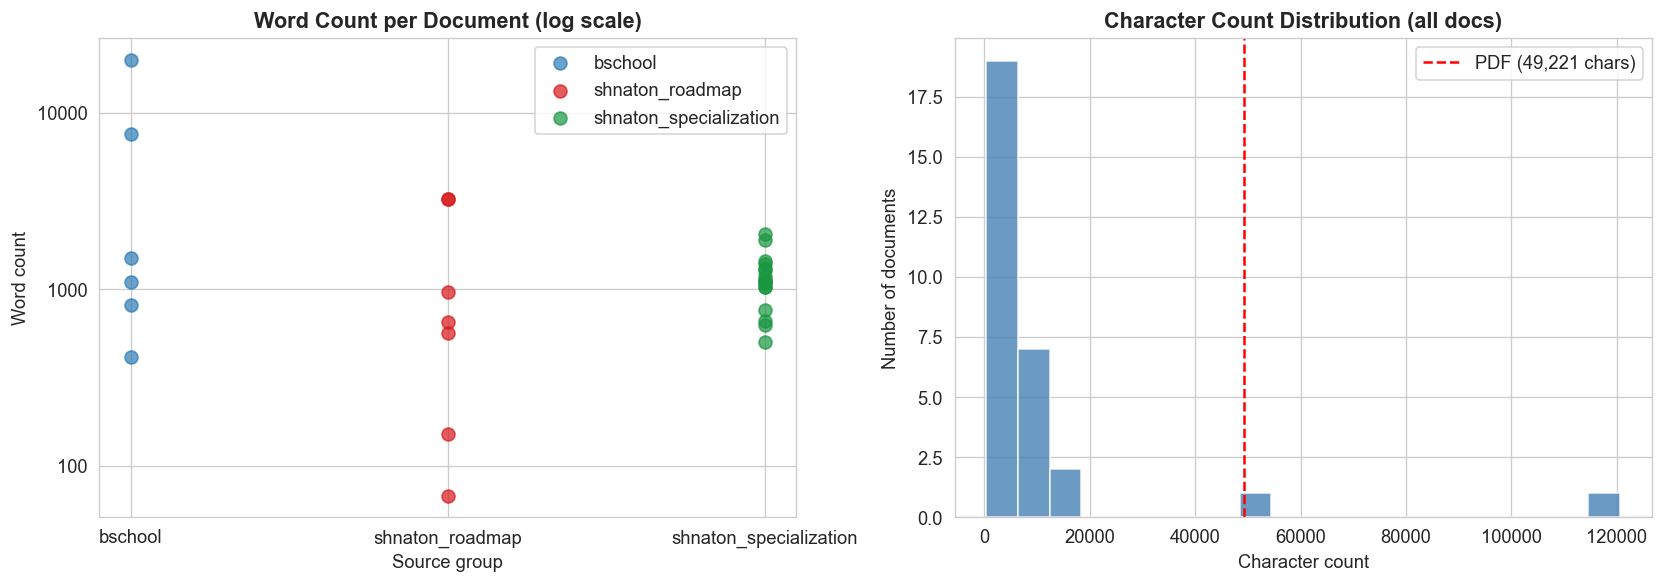

Saved → figures/01_length_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution (log scale)
for group, color in GROUP_PALETTE.items():
    group_data = corpus_df[corpus_df["group"] == group]["word_count"]
    axes[0].scatter(
        [group] * len(group_data),
        group_data,
        alpha=0.7,
        color=color,
        s=60,
        label=group,
        zorder=3,
    )

axes[0].set_yscale("log")
axes[0].set_title("Word Count per Document (log scale)")
axes[0].set_ylabel("Word count")
axes[0].set_xlabel("Source group")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())

# Char count histogram
axes[1].hist(
    corpus_df["char_count"],
    bins=20,
    color="steelblue",
    edgecolor="white",
    alpha=0.8,
)
axes[1].set_title("Character Count Distribution (all docs)")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Number of documents")

# Annotate the PDF outlier if visible
pdf_row = corpus_df[corpus_df["extension"] == ".pdf"]
if not pdf_row.empty:
    pdf_chars = pdf_row["char_count"].values[0]
    axes[1].axvline(pdf_chars, color="red", linestyle="--", linewidth=1.5, label=f"PDF ({pdf_chars:,.0f} chars)")
    axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_length_distribution.png", bbox_inches="tight")
plt.show()
print("Saved → figures/01_length_distribution.png")

---
## Section 3 — Language Ratios

Each document is decomposed into fraction of **Hebrew characters**, **English characters**, **digits**, and **other** (spaces, punctuation, etc.) using Unicode code-point ranges — no model needed.

**Why it matters:** A document that is <20% Hebrew is suspicious (may be boilerplate or failed extraction). Mixed Hebrew/English docs need special handling for embeddings.

In [7]:
lang_cols = ["hebrew_ratio", "english_ratio", "digit_ratio", "other_ratio"]
lang_by_group = corpus_df.groupby("group")[lang_cols].mean().round(3)
print("Mean language ratios by group:")
print(lang_by_group)

Mean language ratios by group:
                        hebrew_ratio  english_ratio  digit_ratio  other_ratio
group                                                                        
bschool                        0.690          0.043        0.037        0.229
shnaton_roadmap                0.613          0.010        0.074        0.302
shnaton_specialization         0.626          0.010        0.072        0.292


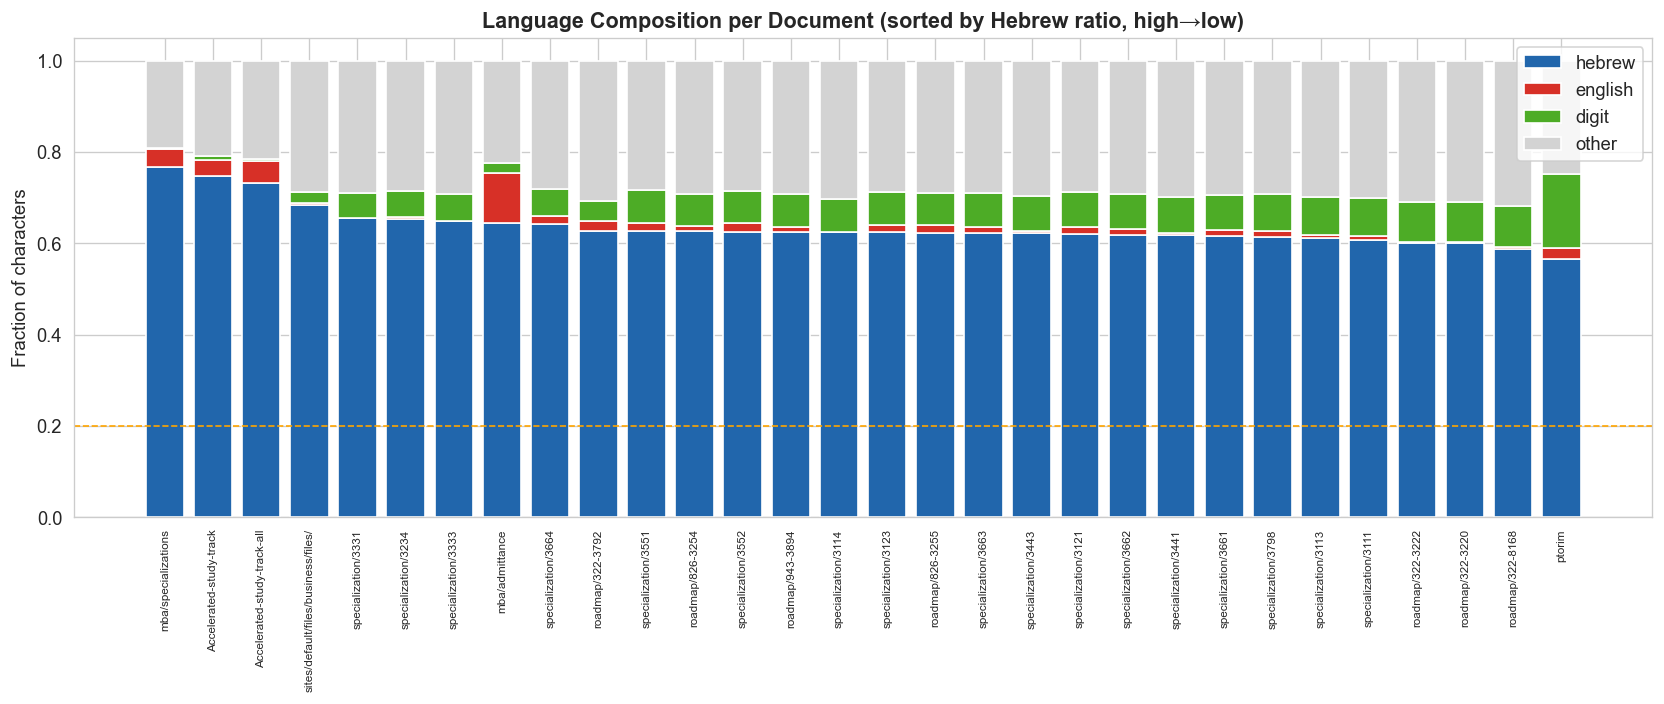

Saved → figures/02_language_ratios.png

All documents have hebrew_ratio ≥ 0.20 ✓


In [8]:
# Stacked bar chart: one bar per document, sorted by hebrew_ratio
lang_sorted_df = corpus_df.sort_values("hebrew_ratio", ascending=False).reset_index(drop=True)
lang_sorted_df["doc_label"] = (
    lang_sorted_df["url"]
    .str.replace(r"https?://[^/]+/", "", regex=True)
    .str[:35]
)

fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(lang_sorted_df))
lang_colors = {"hebrew_ratio": "#2166ac", "english_ratio": "#d73027", "digit_ratio": "#4dac26", "other_ratio": "#d3d3d3"}

for col, color in lang_colors.items():
    values = lang_sorted_df[col].values
    ax.bar(range(len(lang_sorted_df)), values, bottom=bottom, color=color, label=col.replace("_ratio", ""), width=0.8)
    bottom += values

ax.set_xticks(range(len(lang_sorted_df)))
ax.set_xticklabels(lang_sorted_df["doc_label"], rotation=90, fontsize=7)
ax.set_ylabel("Fraction of characters")
ax.set_title("Language Composition per Document (sorted by Hebrew ratio, high→low)")
ax.legend(loc="upper right")
ax.axhline(0.2, color="orange", linestyle="--", linewidth=1, label="20% Hebrew threshold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_language_ratios.png", bbox_inches="tight")
plt.show()
print("Saved → figures/02_language_ratios.png")

# Flag low-Hebrew docs
low_hebrew_df = corpus_df[corpus_df["hebrew_ratio"] < 0.2][["group", "url", "hebrew_ratio", "english_ratio"]]
if not low_hebrew_df.empty:
    print(f"\nDocuments with hebrew_ratio < 0.20 ({len(low_hebrew_df)} docs):")
    print(low_hebrew_df.to_string(index=False))
else:
    print("\nAll documents have hebrew_ratio ≥ 0.20 ✓")

---
## Section 4 — Niqqud (Vowel Marks) & Unicode Normalization

**Niqqud** are Hebrew vowel marks (U+05B0–U+05BC). Modern academic Hebrew text is almost never vocalized, but if niqqud is present it must be stripped before tokenization — most embedding models and tokenizers do not handle it gracefully.

**Unicode NFC normalization:** Some Hebrew sources use non-canonical Unicode forms (presentation characters, alternative forms of final letters). If `NFC(text) ≠ text`, the document needs normalization in the preprocessing pipeline.

In [9]:
# Niqqud summary
niqqud_present = corpus_df[corpus_df["niqqud_ratio"] > 0]
print(f"Documents with niqqud present: {len(niqqud_present)}/{len(corpus_df)}")

if not niqqud_present.empty:
    print("\nNiqqud details:")
    print(
        niqqud_present[["group", "url", "niqqud_char_count", "niqqud_ratio"]]
        .sort_values("niqqud_ratio", ascending=False)
        .to_string(index=False)
    )
else:
    print("No niqqud found in any document ✓")

Documents with niqqud present: 1/30

Niqqud details:
  group                               url  niqqud_char_count  niqqud_ratio
bschool https://bschool.huji.ac.il/ptorim                  2      0.000029


In [10]:
# NFC normalization audit
needs_norm = corpus_df[corpus_df["needs_nfc_normalization"] == True]
print(f"Documents needing NFC normalization: {len(needs_norm)}/{len(corpus_df)}")

if not needs_norm.empty:
    print("\nNormalization details:")
    print(
        needs_norm[["group", "url", "nfc_changed_char_count"]]
        .sort_values("nfc_changed_char_count", ascending=False)
        .to_string(index=False)
    )
else:
    print("All documents are already NFC-normalized ✓")

Documents needing NFC normalization: 0/30
All documents are already NFC-normalized ✓


---
## Section 5 — RTL/LTR Script Mixing Inside Paragraphs

When English course names or acronyms appear inside Hebrew paragraphs, the paragraph switches script direction. Sentences with many switches are harder to segment accurately — a naive splitter may confuse the boundary of a Hebrew sentence with the end of an embedded English phrase.

**Why it matters:** High switch counts = we'll need a Hebrew-aware sentence splitter, not a generic one.

In [11]:
lang_switch_cols = ["mean_lang_switches_per_para", "max_lang_switches_in_para"]
switch_by_group = corpus_df.groupby("group")[lang_switch_cols].mean().round(2)
print("Mean RTL/LTR language switches per paragraph, by group:")
print(switch_by_group)

print("\nTop 10 docs by mean language switches per paragraph:")
top_switch = corpus_df.nlargest(10, "mean_lang_switches_per_para")[["group", "url", "mean_lang_switches_per_para", "max_lang_switches_in_para"]]
print(top_switch.to_string(index=False))

Mean RTL/LTR language switches per paragraph, by group:
                        mean_lang_switches_per_para  max_lang_switches_in_para
group                                                                         
bschool                                        6.90                      58.67
shnaton_roadmap                                0.83                       5.71
shnaton_specialization                         0.48                       4.18

Top 10 docs by mean language switches per paragraph:
          group                                                                                                            url  mean_lang_switches_per_para  max_lang_switches_in_para
        bschool                                                                              https://bschool.huji.ac.il/ptorim                        33.30                        304
        bschool https://bschool.huji.ac.il/sites/default/files/business/files/academic_regulations_for_masters_programs_01.pdf   

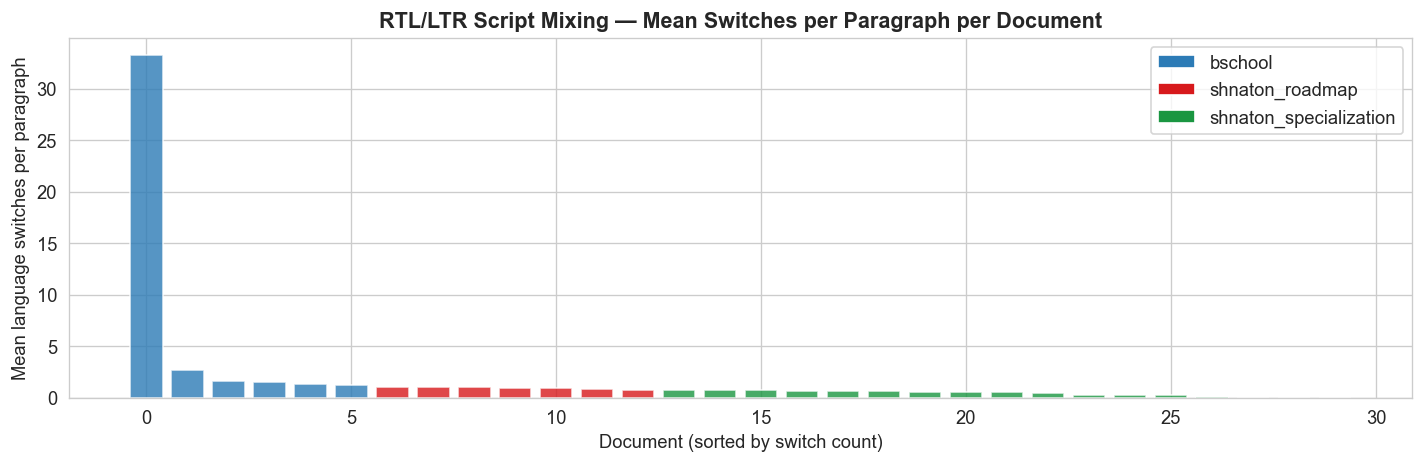

Saved → figures/03_rtl_ltr_mixing.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = corpus_df["group"].map(GROUP_PALETTE)
ax.bar(
    range(len(corpus_df)),
    corpus_df.sort_values("mean_lang_switches_per_para", ascending=False)["mean_lang_switches_per_para"],
    color=colors.values,
    alpha=0.8,
)
ax.set_xlabel("Document (sorted by switch count)")
ax.set_ylabel("Mean language switches per paragraph")
ax.set_title("RTL/LTR Script Mixing — Mean Switches per Paragraph per Document")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in GROUP_PALETTE.items()]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_rtl_ltr_mixing.png", bbox_inches="tight")
plt.show()
print("Saved → figures/03_rtl_ltr_mixing.png")

---
## Section 6 — Hebrew Morphology: Prefix Attachment

Hebrew prefixes (ה, ו, ב, ל, מ, ש, כ) attach directly to words: `קורס` (course) and `הקורס` (the course) are two different tokens for any model that doesn't include morphological analysis.

This section counts how many *prefix-variant pairs* exist — cases where the same base word appears both with and without a prefix in the corpus. **A high count means a morphological normalizer is needed at indexing time.**

In [13]:
prefix_by_group = corpus_df.groupby("group")["prefix_variant_pair_count"].agg(["mean", "max", "sum"]).round(0)
print("Hebrew prefix-variant pair counts by group:")
print(prefix_by_group)

print("\nTop 10 docs by prefix-variant pair count:")
top_prefix = corpus_df.nlargest(10, "prefix_variant_pair_count")[["group", "url", "prefix_variant_pair_count"]]
print(top_prefix.to_string(index=False))

Hebrew prefix-variant pair counts by group:
                         mean  max  sum
group                                  
bschool                 160.0  429  958
shnaton_roadmap          39.0   88  275
shnaton_specialization   27.0   46  460

Top 10 docs by prefix-variant pair count:
                 group                                                                                                            url  prefix_variant_pair_count
               bschool https://bschool.huji.ac.il/sites/default/files/business/files/academic_regulations_for_masters_programs_01.pdf                        429
               bschool                                                                 https://bschool.huji.ac.il/mba/specializations                        174
               bschool                                                                              https://bschool.huji.ac.il/ptorim                        168
       shnaton_roadmap                                               

In [14]:
# Load a sample of prefix variant examples from clean JSON files
prefix_examples = []

for _, row in corpus_df.head(5).iterrows():
    url = row["url"]
    # Re-run measure_prefix_attachment on the saved clean text
    url_stem = __import__("hashlib").sha1(url.encode()).hexdigest()
    clean_txt = CLEAN_DIR / f"{url_stem}.txt"
    if clean_txt.exists():
        import sys
        sys.path.insert(0, str(RAG_EDA_DIR))
        from src.eda_utils import measure_prefix_attachment
        text = clean_txt.read_text(encoding="utf-8")
        result = measure_prefix_attachment(text)
        for ex in result["prefix_variant_examples"][:3]:
            ex["source_group"] = row["group"]
            prefix_examples.append(ex)

if prefix_examples:
    examples_df = pd.DataFrame(prefix_examples)[["source_group", "prefix", "bare_word", "prefixed_word"]]
    print("Sample prefix-variant pairs found in corpus:")
    print(examples_df.to_string(index=False))
else:
    print("Could not load prefix examples (clean text files not found — run eda.py first)")

Sample prefix-variant pairs found in corpus:
source_group prefix bare_word prefixed_word
     bschool      ל      ציון         לציון
     bschool      ב     כלכלה        בכלכלה
     bschool      ב  חשבונאות     בחשבונאות
     bschool      ו     הכלים        והכלים
     bschool      ו      מקנה         ומקנה
     bschool      ב     כלכלה        בכלכלה
     bschool      ב     כלכלה        בכלכלה
     bschool      ה      חובה         החובה
     bschool      ל     תעופה        לתעופה
     bschool      ו    המערכת       והמערכת
     bschool      ה      חובה         החובה
     bschool      ה     ראשון        הראשון
     bschool      ו    המערכת       והמערכת
     bschool      ה      חובה         החובה
     bschool      ה     ראשון        הראשון


---
## Section 7 — Structural Signals (Headings, Lists, Tables)

We count **headings** (H1/H2/H3), **list items**, and **table rows** per document.

**Why it matters:** Shnaton roadmap and specialization pages are likely table-heavy (course code / name / credits per row). The regulations PDF is likely heading-heavy (chapter sections). These structural types will require different chunking strategies in the next stage.

In [15]:
structure_cols = ["h1_count", "h2_count", "h3_count", "list_item_count", "table_row_count"]
structure_by_group = corpus_df.groupby("group")[structure_cols].sum().astype(int)
print("Structural signal totals by group:")
print(structure_by_group)

print("\nTop 10 table-heavy docs:")
print(
    corpus_df.nlargest(10, "table_row_count")[["group", "url", "table_row_count", "h2_count"]]
    .to_string(index=False)
)

Structural signal totals by group:
                        h1_count  h2_count  h3_count  list_item_count  \
group                                                                   
bschool                        0        25        48               61   
shnaton_roadmap                7         9        31              465   
shnaton_specialization        17        31       128              835   

                        table_row_count  
group                                    
bschool                              36  
shnaton_roadmap                     465  
shnaton_specialization              835  

Top 10 table-heavy docs:
                 group                                            url  table_row_count  h2_count
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/322-3220              186         2
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/322-3222              185         2
shnaton_specialization https://shnaton.huji.ac.il/specialization/3113   

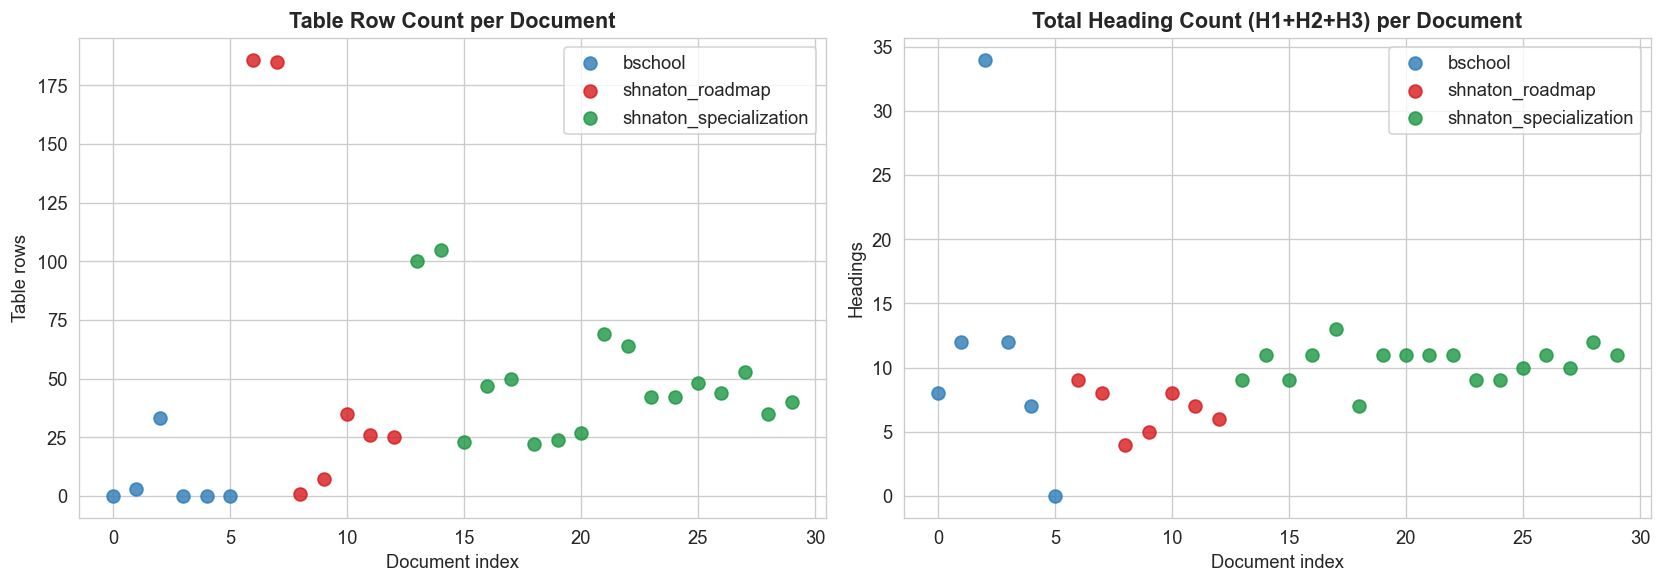

Saved → figures/04_structural_signals.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Table rows per doc
for group, color in GROUP_PALETTE.items():
    gdf = corpus_df[corpus_df["group"] == group]
    axes[0].scatter(gdf.index, gdf["table_row_count"], color=color, label=group, alpha=0.8, s=60)
axes[0].set_title("Table Row Count per Document")
axes[0].set_ylabel("Table rows")
axes[0].set_xlabel("Document index")
axes[0].legend()

# Headings per doc
total_headings = corpus_df["h1_count"] + corpus_df["h2_count"] + corpus_df["h3_count"]
for group, color in GROUP_PALETTE.items():
    mask = corpus_df["group"] == group
    axes[1].scatter(corpus_df[mask].index, total_headings[mask], color=color, label=group, alpha=0.8, s=60)
axes[1].set_title("Total Heading Count (H1+H2+H3) per Document")
axes[1].set_ylabel("Headings")
axes[1].set_xlabel("Document index")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_structural_signals.png", bbox_inches="tight")
plt.show()
print("Saved → figures/04_structural_signals.png")

---
## Section 8 — Numeric Density

We measure what fraction of each document is numeric content (digits and lines with multiple number sequences).

**Why it matters:** Documents that are mostly numbers and table rows (e.g., roadmaps listing course codes and credit counts) behave very differently from prose documents in RAG. High numeric density = the chunk likely carries structured tabular data that needs to stay together.

In [17]:
numeric_by_group = corpus_df.groupby("group")[["digit_char_ratio", "numeric_line_ratio"]].mean().round(3)
print("Mean numeric density by group:")
print(numeric_by_group)

print("\nTop 10 numeric-heavy docs:")
print(
    corpus_df.nlargest(10, "numeric_line_ratio")[["group", "url", "digit_char_ratio", "numeric_line_ratio"]]
    .to_string(index=False)
)

Mean numeric density by group:
                        digit_char_ratio  numeric_line_ratio
group                                                       
bschool                            0.037               0.095
shnaton_roadmap                    0.074               0.485
shnaton_specialization             0.072               0.460

Top 10 numeric-heavy docs:
                 group                                            url  digit_char_ratio  numeric_line_ratio
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/322-3222            0.0870              0.8017
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/322-3220            0.0869              0.7890
shnaton_specialization https://shnaton.huji.ac.il/specialization/3111            0.0839              0.6624
shnaton_specialization https://shnaton.huji.ac.il/specialization/3113            0.0819              0.6587
shnaton_specialization https://shnaton.huji.ac.il/specialization/3441            0.0786         

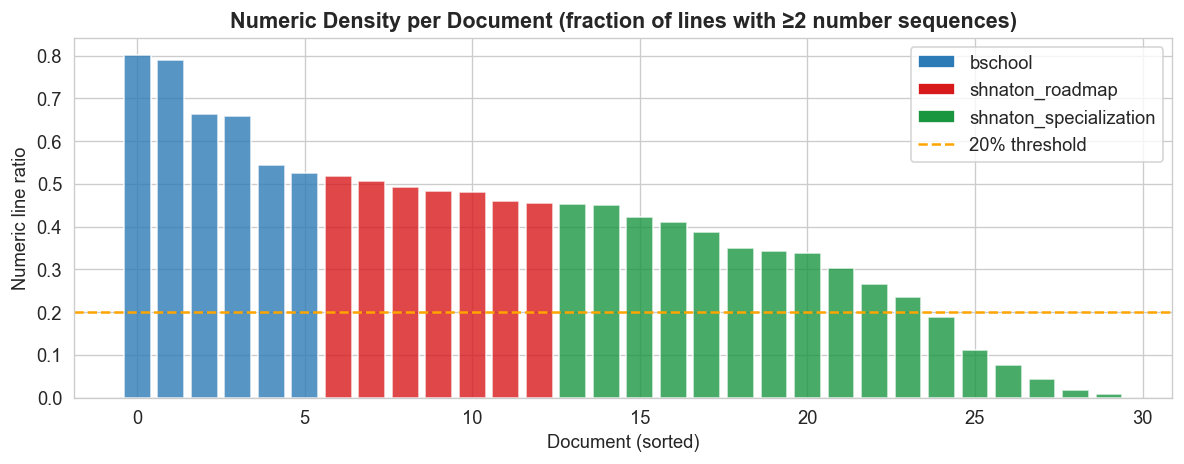

Saved → figures/05_numeric_density.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = corpus_df["group"].map(GROUP_PALETTE)
ax.bar(range(len(corpus_df)), corpus_df.sort_values("numeric_line_ratio", ascending=False)["numeric_line_ratio"],
       color=colors.values, alpha=0.8)
ax.axhline(0.2, color="orange", linestyle="--", linewidth=1.5, label="20% threshold")
ax.set_xlabel("Document (sorted)")
ax.set_ylabel("Numeric line ratio")
ax.set_title("Numeric Density per Document (fraction of lines with ≥2 number sequences)")

legend_elements = [Patch(facecolor=c, label=g) for g, c in GROUP_PALETTE.items()]
legend_elements.append(plt.Line2D([0], [0], color="orange", linestyle="--", label="20% threshold"))
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_numeric_density.png", bbox_inches="tight")
plt.show()
print("Saved → figures/05_numeric_density.png")

---
## Section 9 — Domain Entity Inventory

We count occurrences of the key **domain facts** the corpus contains:
- **Course codes** (e.g., `55-234`, `322-3220`)
- **Credit mentions** (`נ"ז`)
- **Semester/year references**
- **GPA threshold mentions**

**Why it matters:** This tells us *what kind of factual information* the corpus contains, and in which source groups it's concentrated. If GPA thresholds only appear in 2 documents, RAG will have thin coverage for those queries.

In [19]:
entity_cols = ["course_code_count", "credit_mention_count", "semester_mention_count", "gpa_mention_count", "year_mention_count"]

entity_by_group = corpus_df.groupby("group")[entity_cols].sum().astype(int)
print("Domain entity counts by source group:")
print(entity_by_group)

print("\nPer-document entity summary:")
print(
    corpus_df[["group", "url"] + entity_cols]
    .sort_values("course_code_count", ascending=False)
    .head(15)
    .to_string(index=False)
)

Domain entity counts by source group:
                        course_code_count  credit_mention_count  \
group                                                             
bschool                               154                   224   
shnaton_roadmap                         7                   488   
shnaton_specialization                  0                  1013   

                        semester_mention_count  gpa_mention_count  \
group                                                               
bschool                                     23                 12   
shnaton_roadmap                            320                  0   
shnaton_specialization                     684                  0   

                        year_mention_count  
group                                       
bschool                                  9  
shnaton_roadmap                          0  
shnaton_specialization                   0  

Per-document entity summary:
                 group   

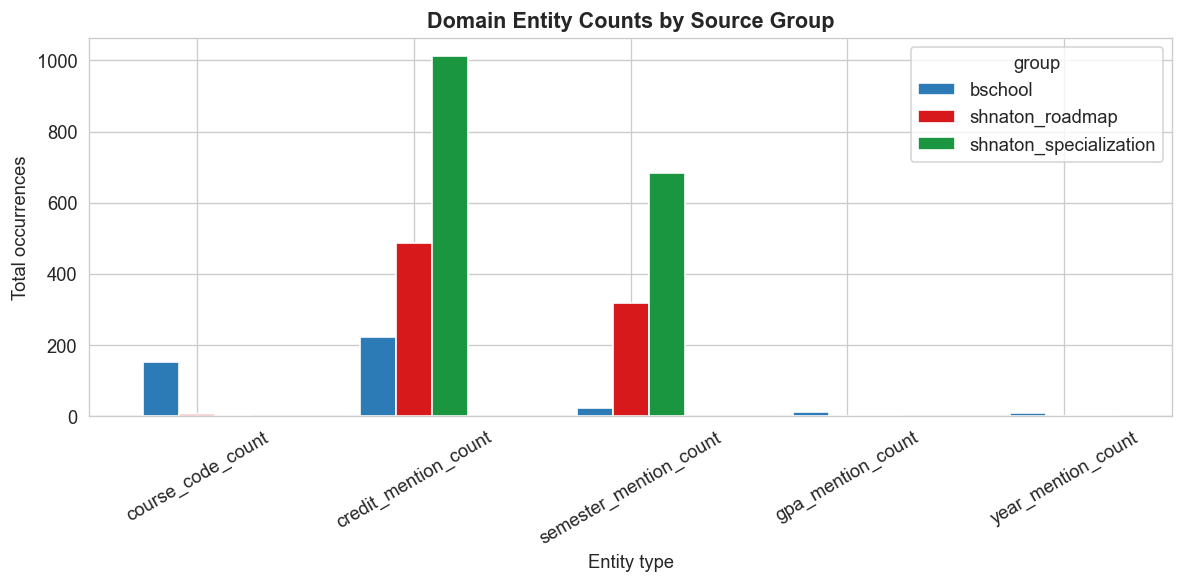

Saved → figures/06_domain_entities.png


In [20]:
entity_by_group_T = entity_by_group.T
fig, ax = plt.subplots(figsize=(10, 5))
entity_by_group_T.plot(kind="bar", ax=ax, color=[GROUP_PALETTE[g] for g in entity_by_group_T.columns], rot=30)
ax.set_title("Domain Entity Counts by Source Group")
ax.set_ylabel("Total occurrences")
ax.set_xlabel("Entity type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_domain_entities.png", bbox_inches="tight")
plt.show()
print("Saved → figures/06_domain_entities.png")

---
## Section 10 — Boilerplate N-grams

We detect **8-word sequences that appear in 5 or more documents** — these are almost certainly navigation menus, cookie banners, site headers, or footers that were not stripped by the extractor.

**Why it matters:** If every chunk from every document contains the same header/footer phrase, embedding similarity between all documents will be artificially inflated. These phrases must be stripped in the preprocessing pipeline.

In [21]:
if BOILERPLATE_PARQUET.exists():
    boilerplate_df = pd.read_parquet(BOILERPLATE_PARQUET)
    print(f"Total boilerplate n-grams found: {len(boilerplate_df)}")
    if not boilerplate_df.empty:
        print("\nTop 20 most-repeated phrases (appearing in most docs):")
        print(boilerplate_df.head(20).to_string(index=False))
    else:
        print("No repeated 8-grams found across ≥5 docs. Boilerplate may have been cleaned by extractor ✓")
else:
    print("boilerplate_ngrams.parquet not found — run eda.py first")

Total boilerplate n-grams found: 940

Top 20 most-repeated phrases (appearing in most docs):
                                             ngram  doc_count
                 ### שנה 1 — חובה חובה ללמוד לפחות         18
                         | 3 נ"ז | סמסטר ב | הקורס         15
              - 55809 | מכרזים ומכירות פומביות | 3         14
   את הקורס מסחר ופרסום אלקטרוניים 55773 אינו ראשי         14
                            | 3 נ"ז | סמסטר א או ב         14
                  - 55916 | תחרות ומבנה שווקים | 3         14
                55916 | תחרות ומבנה שווקים | 3 נ"ז         14
                    | תחרות ומבנה שווקים | 3 נ"ז |         14
                תחרות ומבנה שווקים | 3 נ"ז | סמסטר         14
                    ומבנה שווקים | 3 נ"ז | סמסטר ב         14
                         | 3 נ"ז | סמסטר א | הקורס         14
       אלקטרוניים 55773 אינו ראשי ללמוד קורס זה. -         14
  ופרסום אלקטרוניים 55773 אינו ראשי ללמוד קורס זה.         14
 מסחר ופרסום אלקטרוניים 55773 אינו ראשי

In [22]:
# Show which docs have the most boilerplate hits
if "boilerplate_ngram_hits" in corpus_df.columns:
    print("Documents with most boilerplate n-gram hits:")
    print(
        corpus_df.nlargest(10, "boilerplate_ngram_hits")[["group", "url", "boilerplate_ngram_hits"]]
        .to_string(index=False)
    )

    # Boilerplate-to-word-count ratio (proxy for 'contamination level')
    corpus_df["boilerplate_contamination"] = (
        corpus_df["boilerplate_ngram_hits"] / corpus_df["word_count"].replace(0, np.nan)
    ).fillna(0).round(4)
    print("\nMean boilerplate contamination by group:")
    print(corpus_df.groupby("group")["boilerplate_contamination"].mean().round(4))

Documents with most boilerplate n-gram hits:
                 group                                            url  boilerplate_ngram_hits
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/322-3220                     483
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/322-3222                     483
shnaton_specialization https://shnaton.huji.ac.il/specialization/3443                     307
shnaton_specialization https://shnaton.huji.ac.il/specialization/3441                     294
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/943-3894                     254
shnaton_specialization https://shnaton.huji.ac.il/specialization/3113                     235
       shnaton_roadmap    https://shnaton.huji.ac.il/roadmap/826-3254                     232
shnaton_specialization https://shnaton.huji.ac.il/specialization/3551                     231
shnaton_specialization https://shnaton.huji.ac.il/specialization/3552                     230
       shnaton_

---
## Section 11 — Near-Duplicates (Jaccard Similarity Heatmap)

We compute pairwise word-shingle Jaccard similarity for all 30 document pairs.
- Score > 0.5 = **near-duplicate** (substantial content overlap)
- Score > 0.8 = **likely duplicate** (should be merged or one dropped)

**Why it matters:** Indexing duplicate content wastes vector store space and inflates retrieval scores — the same chunk gets retrieved multiple times, pushing out diverse results.

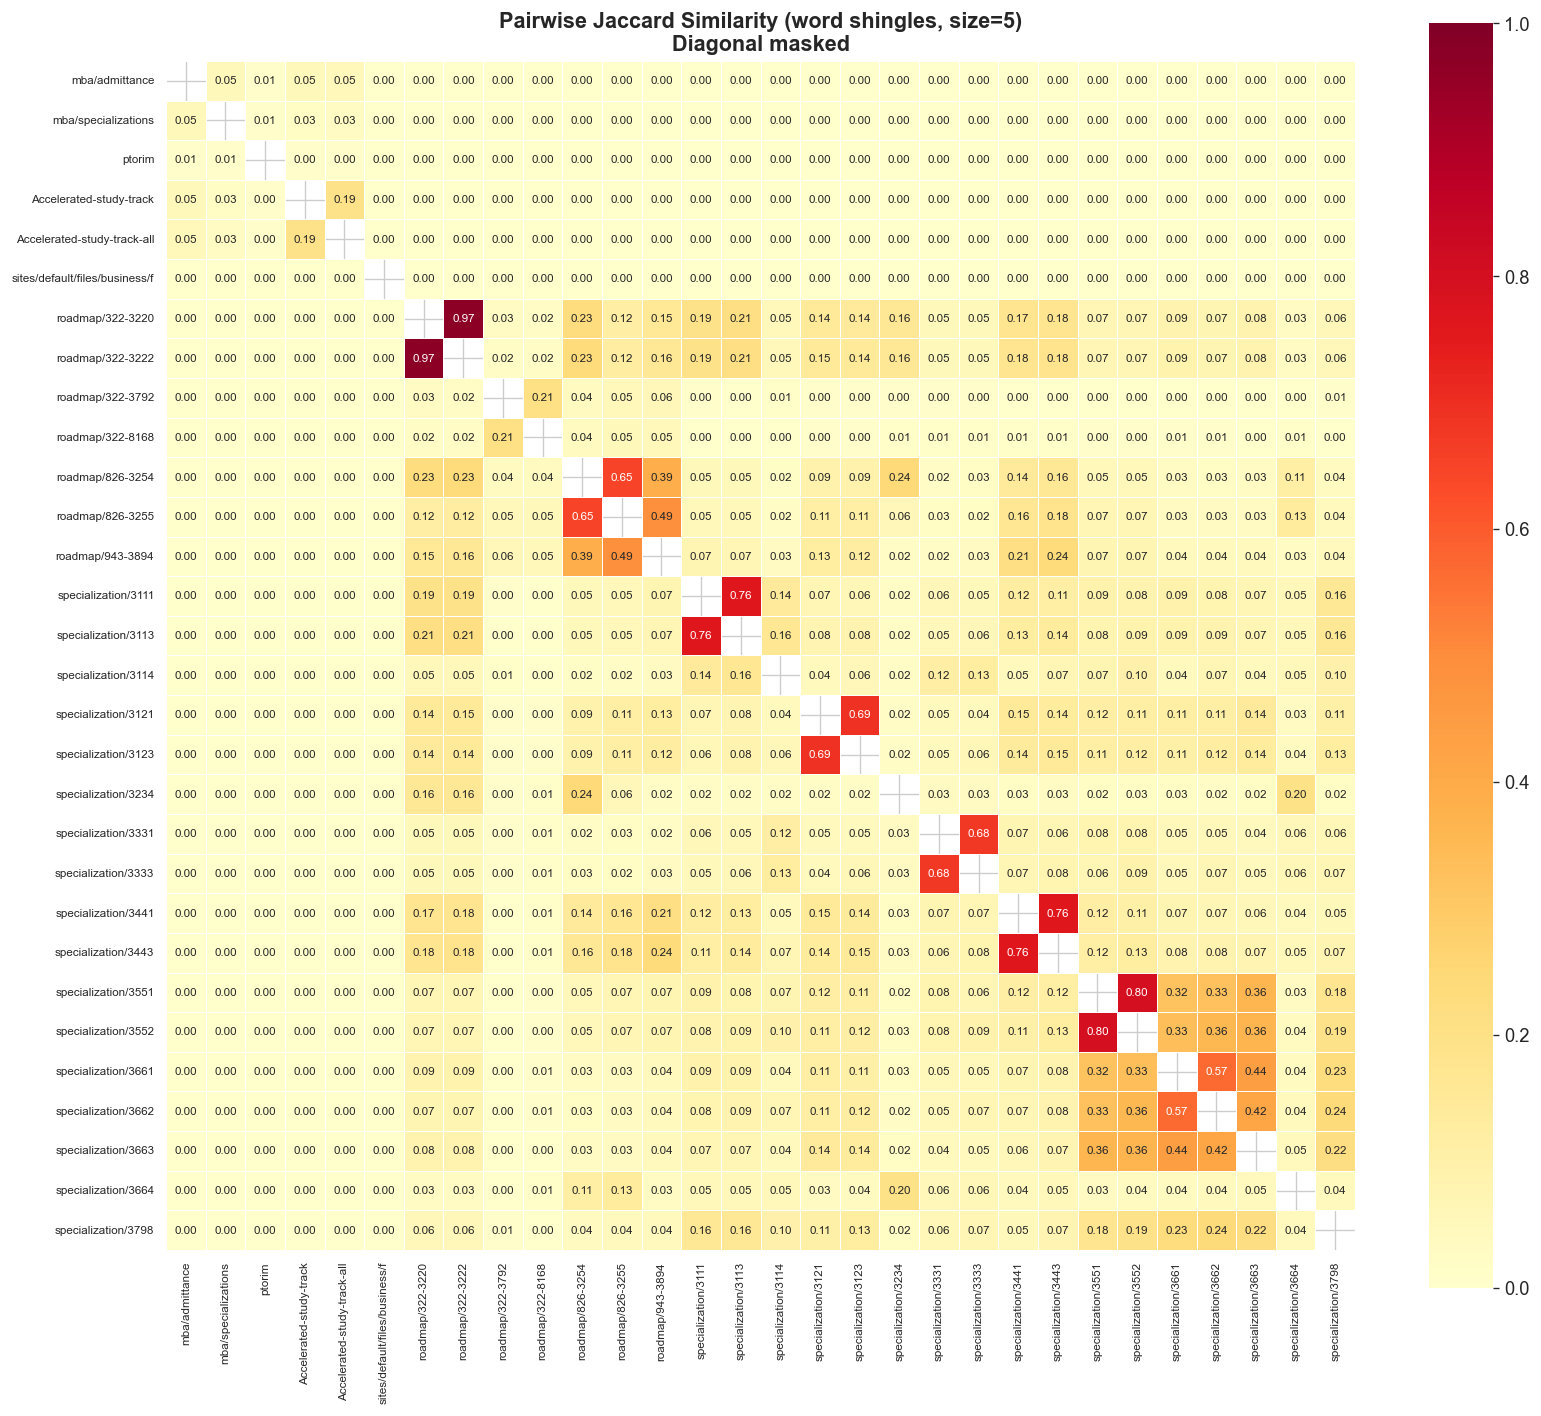

Saved → figures/07_jaccard_heatmap.png

Near-duplicate pairs (Jaccard ≥ 0.5):
              doc_a               doc_b  jaccard
   roadmap/322-3220    roadmap/322-3222    0.969
specialization/3551 specialization/3552    0.801
specialization/3111 specialization/3113    0.764
specialization/3441 specialization/3443    0.763
specialization/3121 specialization/3123    0.693
specialization/3331 specialization/3333    0.677
   roadmap/826-3254    roadmap/826-3255    0.649
specialization/3661 specialization/3662    0.567


In [23]:
if JACCARD_NPY.exists():
    jaccard_matrix = np.load(JACCARD_NPY)

    # Short URL labels for axes
    url_labels = (
        corpus_df["url"]
        .str.replace(r"https?://[^/]+/", "", regex=True)
        .str[:30]
        .tolist()
    )

    n = len(jaccard_matrix)
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.eye(n, dtype=bool)  # mask diagonal (self-similarity = 1.0)
    sns.heatmap(
        jaccard_matrix,
        mask=mask,
        xticklabels=url_labels,
        yticklabels=url_labels,
        cmap="YlOrRd",
        vmin=0, vmax=1,
        ax=ax,
        linewidths=0.3,
        annot=(n <= 30),
        fmt=".2f" if n <= 30 else "",
        annot_kws={"size": 7},
        square=True,
    )
    ax.set_title("Pairwise Jaccard Similarity (word shingles, size=5)\nDiagonal masked")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "07_jaccard_heatmap.png", bbox_inches="tight")
    plt.show()
    print("Saved → figures/07_jaccard_heatmap.png")

    # List high-overlap pairs
    NEAR_DUP_THRESHOLD = 0.5
    near_dup_pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if jaccard_matrix[i, j] >= NEAR_DUP_THRESHOLD:
                near_dup_pairs.append({
                    "doc_a": url_labels[i],
                    "doc_b": url_labels[j],
                    "jaccard": round(jaccard_matrix[i, j], 3),
                })

    if near_dup_pairs:
        near_dup_df = pd.DataFrame(near_dup_pairs).sort_values("jaccard", ascending=False)
        print(f"\nNear-duplicate pairs (Jaccard ≥ {NEAR_DUP_THRESHOLD}):")
        print(near_dup_df.to_string(index=False))
    else:
        print(f"No near-duplicate pairs found (all Jaccard scores < {NEAR_DUP_THRESHOLD}) ✓")
else:
    print("jaccard_matrix.npy not found — run eda.py first")

---
## Section 12 — PDF Sanity Check

The academic regulations PDF (`academic_regulations_for_masters_programs_01.pdf`) is the only PDF in the corpus. Hebrew PDFs have known extraction issues:
- **Reversed text:** visual-order rendering can produce RTL-flipped output
- **Broken ligatures:** some PDF generators merge Hebrew letters incorrectly
- **Sentence-segmentation:** abbreviations like `ד"ר`, `פרופ'`, `וכו'` mislead naive splitters

We inspect a text sample and report what we find.

In [24]:
pdf_rows = corpus_df[corpus_df["extension"] == ".pdf"]

if pdf_rows.empty:
    print("No PDF documents found in corpus.")
else:
    for _, pdf_row in pdf_rows.iterrows():
        print(f"PDF: {pdf_row['url']}")
        print(f"  Word count:          {pdf_row['word_count']:,}")
        print(f"  Char count:          {pdf_row['char_count']:,}")
        print(f"  Hebrew ratio:        {pdf_row['hebrew_ratio']:.1%}")
        print(f"  Direction check OK:  {pdf_row.get('pdf_direction_ok', 'N/A')}")
        print(f"  Direction message:   {pdf_row.get('pdf_direction_message', 'N/A')}")
        print(f"  Extraction warnings: {pdf_row['extraction_warnings']}")

PDF: https://bschool.huji.ac.il/sites/default/files/business/files/academic_regulations_for_masters_programs_01.pdf
  Word count:          7,596
  Char count:          49,221
  Hebrew ratio:        68.3%
  Direction check OK:  True
  Direction message:   Found 7/16 expected Hebrew function-words. Direction appears correct.
  Extraction warnings: 


In [25]:
# Print a text sample from the PDF for manual inspection
if not pdf_rows.empty:
    pdf_url = pdf_rows.iloc[0]["url"]
    import hashlib
    pdf_stem = hashlib.sha1(pdf_url.encode()).hexdigest()
    pdf_clean_txt = CLEAN_DIR / f"{pdf_stem}.txt"

    if pdf_clean_txt.exists():
        pdf_text = pdf_clean_txt.read_text(encoding="utf-8")
        print("=== First 1,000 characters of extracted PDF text ===")
        print(repr(pdf_text[:1000]))
        print("\n=== Rendered ===")
        print(pdf_text[:1000])
    else:
        print(f"Clean text file not found: {pdf_clean_txt}")

=== First 1,000 characters of extracted PDF text ===
' \n1 \n \n תקנון לימודים לתואר מוסמך במנהל עסקים – MBA \n \nהמסמך שלהלן מיועד לסטודנטים ולסטודנטיות המתחילים את לימודיהם בשנת הלימודים תשפ"ה. המסמך מתאר \nאת: \n\uf0b7 מבנה תוכנית הלימודים ב-MBA \n\uf0b7 אפשרויות צבירת קורסי ה-MBA במקביל ללימודי הבוגר, במסגרת תוכניות המצטיינים של בית הספר \n\uf0b7 תיאור של ההתמחויות השונות ואפשרות השילוב ביניהן \nלמידע על תוכנית תואר שני (MA )ב"כלכלה פיננסית", קראו כאן. \nלנהלי הוראה ולימודים של האגף למנהל הסטודנטים, קראו כאן.  \n  \n\n \n2 \n \nתוכן עניינים \nהסבר על תואר מוסמך במנהל עסקים (MBA :)עבור כלל המסלולים .................................................. 4 \nמבנה תואר המוסמך (MBA )במנהל עסקים ............................................................................... 4 \nהמסלול העיוני .............................................................................................................. 4 \nלימודי תשתית ולימודי חובה כלליים .......................................................

In [26]:
# Sentence segmentation sample across a few docs
print("=== Sentence-segmentation false-split rate across all docs ===")
seg_summary = corpus_df[["group", "url", "sentence_false_split_rate", "total_sentences_found"]].copy()
seg_summary["url_short"] = seg_summary["url"].str.replace(r"https?://[^/]+/", "", regex=True).str[:40]
print(
    seg_summary
    .sort_values("sentence_false_split_rate", ascending=False)
    .head(15)[["group", "url_short", "sentence_false_split_rate", "total_sentences_found"]]
    .to_string(index=False)
)

print(f"\nMean false-split rate across all docs: {corpus_df['sentence_false_split_rate'].mean():.1%}")

=== Sentence-segmentation false-split rate across all docs ===
                 group                                url_short  sentence_false_split_rate  total_sentences_found
       shnaton_roadmap                         roadmap/826-3255                     0.1739                     23
       shnaton_roadmap                         roadmap/826-3254                     0.1333                     30
       shnaton_roadmap                         roadmap/943-3894                     0.1176                     17
shnaton_specialization                      specialization/3443                     0.1000                     30
shnaton_specialization                      specialization/3441                     0.0968                     31
shnaton_specialization                      specialization/3234                     0.0811                     37
shnaton_specialization                      specialization/3552                     0.0690                     29
shnaton_specialization   

---
## Section 13 — Issues Found in the Data

**This section is the output of the EDA.** It summarizes concrete data-quality findings that must be addressed in the preprocessing pipeline before chunking. No modeling decisions are made here.

The findings are populated automatically from the data computed above.

**Key findings from the fully corrected corpus (all 17 specializations, 835 course entries):**

| # | Issue | Severity |
|---|---|---|
| 1 | **Near-duplicates** — 8 pairs with Jaccard ≥ 0.5 (max 0.969) | High |
| 2 | **Hebrew morphology** — 1,693 prefix-variant pairs across corpus | High |
| 3 | **RTL/LTR mixing** — bschool/ptorim has 304 switches in one paragraph | Medium |
| 4 | **Boilerplate** — 940 repeated 8-grams (structural Shnaton phrases, not pure noise) | Low-Medium |
| 5 | **Sentence false-splits** — up to 7.1% in shnaton_roadmap; caused by Hebrew abbreviations | Low |

In [27]:
issues = []
recommendations = []

# ── Fetch errors ──────────────────────────────────────────────────────────────
fetch_errors = corpus_df[corpus_df["word_count"] == 0]
if not fetch_errors.empty:
    issues.append(
        f"FETCH: {len(fetch_errors)} sources failed to fetch or extract "
        f"({list(fetch_errors['url'])})"
    )
    recommendations.append("Retry failed fetches; check if sites require authentication or JS rendering")

# ── Low Hebrew ratio ──────────────────────────────────────────────────────────
low_hebrew = corpus_df[
    (corpus_df["hebrew_ratio"] < 0.2) & (corpus_df["extension"] != ".pdf")
]
if not low_hebrew.empty:
    issues.append(
        f"LANGUAGE: {len(low_hebrew)} non-PDF docs have Hebrew ratio < 20% "
        f"(may be mostly English, or extraction failed)"
    )
    recommendations.append("Inspect low-Hebrew docs manually; check if BeautifulSoup stripped too much content")

# ── Niqqud ────────────────────────────────────────────────────────────────────
niqqud_docs = corpus_df[corpus_df["niqqud_ratio"] > 0.001]
if not niqqud_docs.empty:
    issues.append(
        f"NIQQUD: {len(niqqud_docs)} docs contain niqqud (Hebrew vowel marks) "
        f"which may confuse tokenizers"
    )
    recommendations.append("Strip niqqud (U+05B0–U+05BC) during preprocessing")

# ── NFC normalization ─────────────────────────────────────────────────────────
norm_docs = corpus_df[corpus_df["needs_nfc_normalization"] == True]
if not norm_docs.empty:
    issues.append(
        f"UNICODE: {len(norm_docs)} docs contain non-NFC characters "
        f"(will produce different token IDs for the same visual character)"
    )
    recommendations.append("Apply unicodedata.normalize('NFC', text) to all documents during preprocessing")

# ── Near-duplicates ───────────────────────────────────────────────────────────
if JACCARD_NPY.exists():
    j = np.load(JACCARD_NPY)
    n = len(j)
    high_overlap = sum(1 for i in range(n) for k in range(i+1, n) if j[i,k] >= 0.5)
    if high_overlap > 0:
        issues.append(
            f"DUPLICATES: {high_overlap} document pairs have Jaccard similarity ≥ 0.50 "
            f"(substantial content overlap; indexing both wastes space and inflates retrieval scores)"
        )
        recommendations.append("Deduplicate or merge near-duplicate document pairs before indexing")

# ── Boilerplate ───────────────────────────────────────────────────────────────
if BOILERPLATE_PARQUET.exists():
    bp = pd.read_parquet(BOILERPLATE_PARQUET)
    if not bp.empty:
        issues.append(
            f"BOILERPLATE: {len(bp)} repeated 8-gram phrases appear in ≥5 docs "
            f"(navigation menus, footers, or cookie banners not fully stripped)"
        )
        recommendations.append(f"Extend HTML extractor's noise-tag stripping; strip top boilerplate n-grams from all documents")

# ── High RTL/LTR switching ────────────────────────────────────────────────────
high_switch = corpus_df[corpus_df["mean_lang_switches_per_para"] > 10]
if not high_switch.empty:
    issues.append(
        f"RTL/LTR: {len(high_switch)} docs have >10 mean language switches per paragraph "
        f"(heavy Hebrew/English mixing will challenge sentence splitters)"
    )
    recommendations.append("Use a Hebrew-aware sentence splitter (e.g., tokenize at blank lines for mixed paragraphs)")

# ── High prefix attachment ────────────────────────────────────────────────────
total_prefix_pairs = corpus_df["prefix_variant_pair_count"].sum()
if total_prefix_pairs > 50:
    issues.append(
        f"MORPHOLOGY: {total_prefix_pairs} prefix-variant word pairs found across corpus "
        f"(same root appears with/without Hebrew prefixes ה,ו,ב,ל,מ,ש,כ — naive retrieval will miss prefix variants)"
    )
    recommendations.append("Consider a Hebrew morphological normalizer (HebMorph, Stanza Hebrew) at indexing time, or use a multilingual model that handles sub-word morphology")

# ── PDF direction ─────────────────────────────────────────────────────────────
pdf_bad = corpus_df[(corpus_df["extension"] == ".pdf") & (corpus_df["pdf_direction_ok"] == False)]
if not pdf_bad.empty:
    issues.append(
        f"PDF: {len(pdf_bad)} PDF(s) may have reversed Hebrew text (direction check failed)"
    )
    recommendations.append("Try pdfplumber with layout analysis or a dedicated RTL-aware PDF extractor for the regulations PDF")

# ── Sentence false splits ─────────────────────────────────────────────────────
mean_false_split = corpus_df["sentence_false_split_rate"].mean()
if mean_false_split > 0.15:
    issues.append(
        f"SEGMENTATION: Mean sentence false-split rate = {mean_false_split:.1%} "
        f"(Hebrew abbreviations like ד\"ר, פרופ\' trigger incorrect sentence breaks)"
    )
    recommendations.append("Add an abbreviation exclusion list to the sentence splitter before chunking")

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 70)
print(f"ISSUES FOUND IN THE DATA ({len(issues)} issues)")
print("=" * 70)
for i, issue in enumerate(issues, 1):
    print(f"\n[Issue {i}] {issue}")

print("\n" + "=" * 70)
print(f"PREPROCESSING RECOMMENDATIONS ({len(recommendations)} items)")
print("=" * 70)
for i, rec in enumerate(recommendations, 1):
    print(f"\n[Rec {i}] {rec}")

if not issues:
    print("\nNo major data-quality issues detected. Corpus looks clean ✓")

ISSUES FOUND IN THE DATA (4 issues)

[Issue 1] DUPLICATES: 8 document pairs have Jaccard similarity ≥ 0.50 (substantial content overlap; indexing both wastes space and inflates retrieval scores)

[Issue 2] BOILERPLATE: 940 repeated 8-gram phrases appear in ≥5 docs (navigation menus, footers, or cookie banners not fully stripped)

[Issue 3] RTL/LTR: 1 docs have >10 mean language switches per paragraph (heavy Hebrew/English mixing will challenge sentence splitters)

[Issue 4] MORPHOLOGY: 1693 prefix-variant word pairs found across corpus (same root appears with/without Hebrew prefixes ה,ו,ב,ל,מ,ש,כ — naive retrieval will miss prefix variants)

PREPROCESSING RECOMMENDATIONS (4 items)

[Rec 1] Deduplicate or merge near-duplicate document pairs before indexing

[Rec 2] Extend HTML extractor's noise-tag stripping; strip top boilerplate n-grams from all documents

[Rec 3] Use a Hebrew-aware sentence splitter (e.g., tokenize at blank lines for mixed paragraphs)

[Rec 4] Consider a Hebrew morph

---

## Next Steps

The issues found above feed directly into the **next stage** of the RAG pipeline:

1. **Deduplication** — 8 near-duplicate document pairs (Jaccard 0.57–0.97) must be merged or deduplicated before indexing. Every primary/secondary specialization pair shares a large elective course pool.
2. **Hebrew morphological normalization** — 1,693 prefix-variant pairs across the corpus. The same concept ("ניהול", "בניהול", "לניהול") appears as multiple tokens. Integrate HebMorph, Stanza Hebrew, or a sub-word model at index time.
3. **Selective boilerplate stripping** — strip bschool navigation noise; retain Shnaton structural phrases (they are factual content, not noise).
4. **Chunking strategy** — informed by document structure (Sections 7–8): Shnaton docs are best chunked by course group (H3 section + its course list items). bschool prose pages suit recursive section splitting. The bschool/ptorim page (304 RTL/LTR switches in one paragraph) needs special handling.
5. **Hebrew embedding model selection** — informed by language ratios (Section 3) and morphology findings (Section 6): 62–69% Hebrew ratio + 1,693 prefix pairs = strong case for a Hebrew-native or sub-word-morphology-aware model.

**These decisions are made in the next iteration, not here.**